<a href="https://colab.research.google.com/github/Enerity/Maintenance-Prediction-for-CNC-Machines/blob/main/Maintenance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INTRODUCTION

# DATA LOADING

In [1]:
#first connect the notebook to drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#then load the datset into a dataframe
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Data Projects/Maintenance Prediction/data/data.csv")

In [3]:
#to view and investigate the datafraame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [4]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


From the brief overview of the dataset, This dataset contaains information of various machines involved in manufacturing CNC (Computer Numerical Control) machines:

M-Milling machines
L-Lathes
L-Drilling machines

These are machines that:

Rotate tools at high speed (hence Rotational speed [rpm])
Apply torque (Torque [Nm])
Operate under controlled temperatures (Air temp, Process temp)
Have tools that wear over time (Tool wear [min])

The dataset will be used to predict machine failures before they happen, so all these features come from sensors monitoring these CNC-type machines.

# DATA CLEANING

In [5]:
#to check for missing values
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Target,0
Failure Type,0


In [6]:
#to check forr duplicaatees
df.duplicated().sum()

np.int64(0)

In [7]:
#data review and validation
#a loop to ccheck the info about data contentss in each column
for col in df.columns:
    print(f"Column: {col}")
    print(f" - Nulls: {df[col].isnull().sum()}")
    print(f" - Number of Unique values: {df[col].nunique()}")
    print(f" - Example values: {df[col].unique()[:5]}")
    print()

Column: UDI
 - Nulls: 0
 - Number of Unique values: 10000
 - Example values: [1 2 3 4 5]

Column: Product ID
 - Nulls: 0
 - Number of Unique values: 10000
 - Example values: ['M14860' 'L47181' 'L47182' 'L47183' 'L47184']

Column: Type
 - Nulls: 0
 - Number of Unique values: 3
 - Example values: ['M' 'L' 'H']

Column: Air temperature [K]
 - Nulls: 0
 - Number of Unique values: 93
 - Example values: [298.1 298.2 298.3 298.5 298.4]

Column: Process temperature [K]
 - Nulls: 0
 - Number of Unique values: 82
 - Example values: [308.6 308.7 308.5 309.  308.9]

Column: Rotational speed [rpm]
 - Nulls: 0
 - Number of Unique values: 941
 - Example values: [1551 1408 1498 1433 1425]

Column: Torque [Nm]
 - Nulls: 0
 - Number of Unique values: 577
 - Example values: [42.8 46.3 49.4 39.5 40. ]

Column: Tool wear [min]
 - Nulls: 0
 - Number of Unique values: 246
 - Example values: [0 3 5 7 9]

Column: Target
 - Nulls: 0
 - Number of Unique values: 2
 - Example values: [0 1]

Column: Failure Type
 -

# DATA ANALYSIS

In [ ]:
#data analysis
#To properly analyse this data set, first we will do a distribution check then will figure out if there is a trend in the failures.


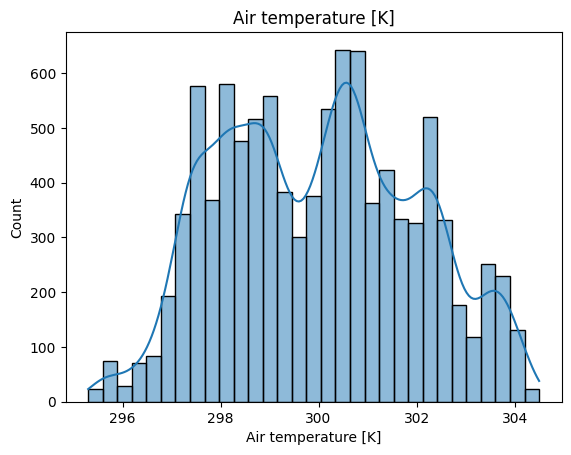

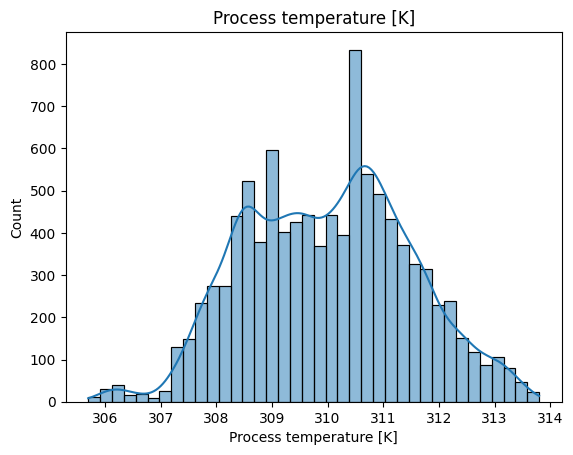

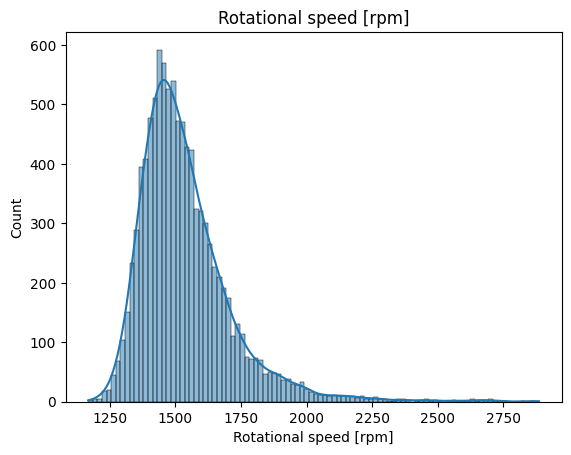

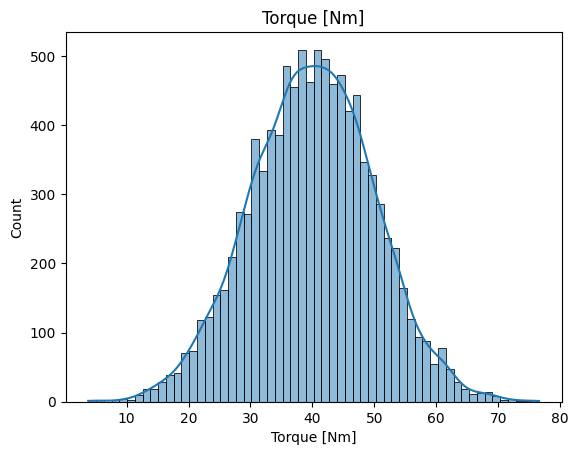

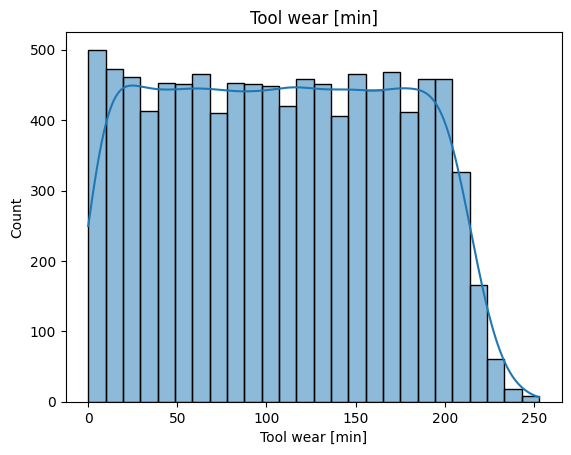

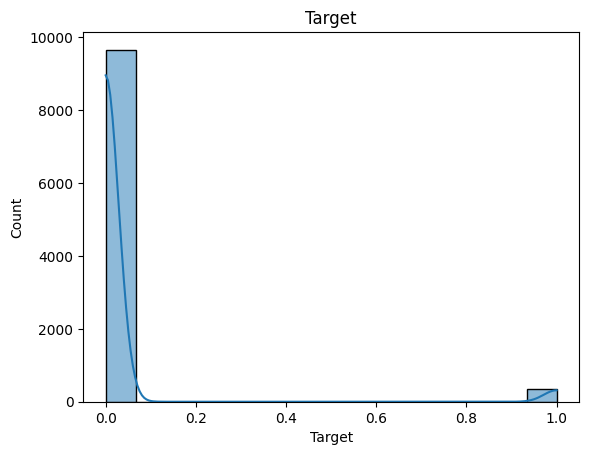

In [8]:
#distribution check
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target']
for col in numeric_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

<Axes: >

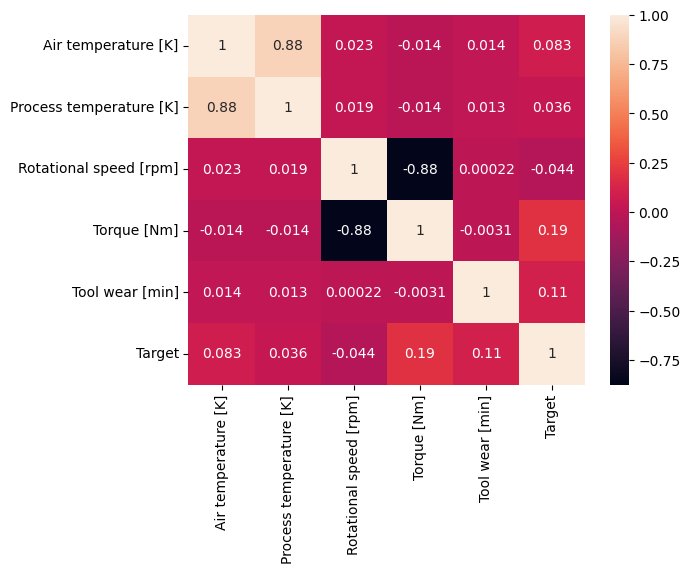

In [9]:
#then i'll check for correlation between numeric features
sns.heatmap(df[numeric_cols].corr(), annot=True)

<Axes: xlabel='Target'>

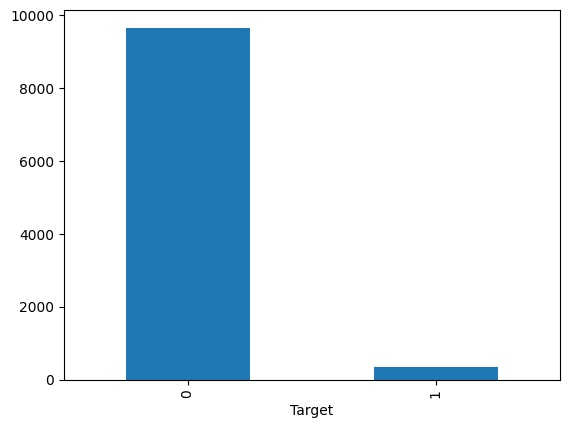

In [10]:
#to check for the distribution for the target column
df['Target'].value_counts().plot(kind='bar')


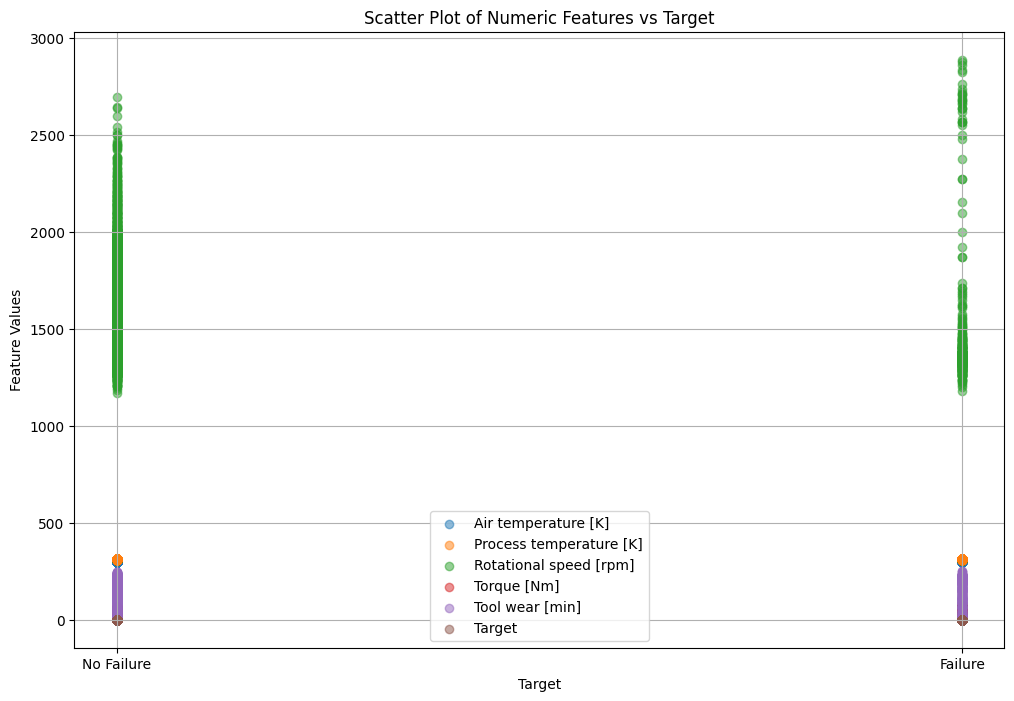

In [11]:
#to check failure by the different features to check which affects failure the mosst
# Group by target and take mean of each numeric column
mean_values = df.groupby('Target')[numeric_cols].mean()

# Plot line chart
plt.figure(figsize=(12,8))

# Loop through numeric columns and plot each as scatter
for col in numeric_cols:
    plt.scatter(df['Target'], df[col], alpha=0.5, label=col)

plt.xticks([0,1], ['No Failure','Failure'])
plt.xlabel('Target')
plt.ylabel('Feature Values')
plt.title('Scatter Plot of Numeric Features vs Target')
plt.grid(True)
plt.legend()
plt.show()



# PREPROCESSING

This will involve encoding categorical columns, and scaling all numerical columns to make sure there is fairness in the training process.


In [12]:
#to encode categorical values likee taarget, failure type and type columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Target'])
df['Type'] = le.fit_transform(df['Type'])
df['Failure Type'] = le.fit_transform(df['Failure Type'])


#to view the encoded values



In [13]:
#to scale the numerical columns dropping the target column
numeric_cols2 = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numeric_cols2] = scaler.fit_transform(df[numeric_cols2])



In [14]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,2,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0,1
1,2,L47181,1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0,1
2,3,L47182,1,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0,1
3,4,L47183,1,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,0,1
4,5,L47184,1,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,0,1


In [19]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')

# DATA SPLITTING AND TRAINING

In [15]:
from re import X
#to drop the target and failure type
X = df.drop(['UDI', 'Product ID', 'Target', 'Failure Type'], axis=1)
y = df['Target']


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.88      0.62      0.72        68

    accuracy                           0.98      2000
   macro avg       0.93      0.81      0.86      2000
weighted avg       0.98      0.98      0.98      2000



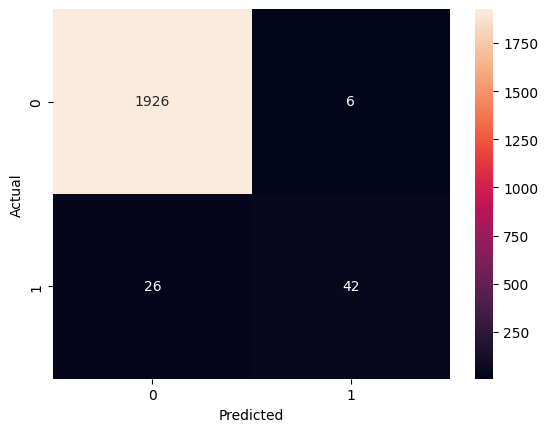

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

From this matrix it says, 1926 correctly detected normal machines, 6 false alarms, 26 missed alarms and 42 correctly detected failures.

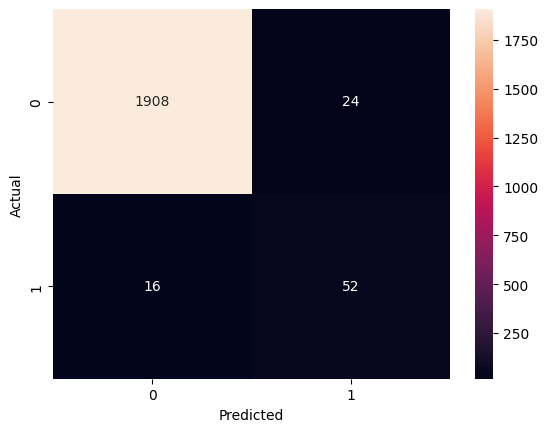

In [23]:
#since the priority is to get as much as possible all the detected failures correctly i.e little or no missed alarms.
#therefore i'll lower the threshold
y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.3).astype(int)

# then plot the matrix again
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [24]:
#to save the model
import joblib
import os

# Define the directory path
model_dir = '../models/'

# Create the directory if it does not exist
os.makedirs(model_dir, exist_ok=True)

# Define the full path for the model file
model_path = os.path.join(model_dir, 'maintenance_prediction_model.pkl')

# Save the model
joblib.dump(model, model_path)

['../models/maintenance_prediction_model.pkl']

In [ ]:
#push to github
